In [1]:
import torch
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
from torch import nn
from sklearn.preprocessing import OrdinalEncoder

from libs import Loader, Solver, Trainer
from libs.models import TransformerModel, Tokenizer
from libs.constants import *
from libs.utils import NDCG, count_polars, count_params, sample_polars

In [2]:
EMB_DIM = 16
NUM_RECENT_VIDEOS = 150
TEST_ITEMS = 5_000

In [67]:
loader = Loader('ur0.01_ir0.01', content_embedding_size=EMB_DIM, val_weeks=2, batch_size=500_000)
((train_df, val_df), test_df), users_df, items_df = loader.load_data(convert_to_pandas=False)

Create lazy interaction datasets
Load metadata
Get unique users/items


  0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

Filter embeddings
Process metadata
Calculate features
Compute aggregates


  0%|          | 0/7 [00:00<?, ?it/s]

Filter interactions
Finalize interactions
Count
train: 53_070 val: 3_605 test: 1_346
user_id: 2_022 item_id: 113_942


In [68]:
train_df: pl.LazyFrame = train_df.filter(pl.col(TARGET) > 0)  # Interaction: positive
val_df: pl.LazyFrame = val_df.filter(pl.col(TARGET) > 0)  # Interaction: positive
test_df: pl.LazyFrame = test_df.filter(pl.col(TARGET) > 0)  # Interaction: positive

print(f"Train: {count_polars(train_df):_} Val: {count_polars(val_df):_} Test: {count_polars(test_df):_}")

Train: 52_968 Val: 3_597 Test: 1_340


In [69]:
user_categories = [users_df.select(pl.n_unique(col)).collect().item() for col in USER_FEATURES[CATEGORICAL]]

In [71]:
user_oe = OrdinalEncoder(dtype=np.long)
user_oe.fit(users_df.select(USER_FEATURES[CATEGORICAL]).collect())
users_cat = user_oe.transform(users_df.select(USER_FEATURES[CATEGORICAL]).collect())
users_encoded = users_df.with_columns(
    **pl.LazyFrame(users_cat, USER_FEATURES[CATEGORICAL]).collect().to_dict()
)

In [72]:
all_authors = items_df.select(pl.col(AUTHOR).unique()).collect()[AUTHOR].to_list()
idx_to_author = dict(enumerate([None] + all_authors))
author_to_idx = {v: k for k, v in idx_to_author.items()}
items_encoded = items_df.with_columns(
    pl.col(AUTHOR).replace(author_to_idx).alias(AUTHOR)
)

In [74]:
model = TransformerModel(
    item_embedding_dim=EMB_DIM,
    # user_tokenizer = Tokenizer(
    #     categories=user_categories,
    # ),
    # author_embedding=nn.Embedding(len(author_to_idx), 16, padding_idx=0),
    hidden_dim=64,
    num_layers=2,
    nheads=8,
    dim_feedforward=128,
    dropout=0.5,
    trainable_position=True,
    max_seq_len=NUM_RECENT_VIDEOS,
    use_multi_target=False,
)
# TODO add target encoding
# TODO implement multi target


# model = RNNModel(
#     in_dim=EMB_DIM,
#     hidden_dim=128,
#     layer='lstm',
#     num_layers=2,
#     dropout=0.5,
# )

# model = WeightedAvgModel(
#     method='add',
#     temporal_distribution='linear',
#     alpha=0.5,
# )

print(f"Params: {count_params(model):_}")

Params: 861_632


In [75]:
trainer = Trainer(
    model=model,
    train_interactions=train_df,
    val_interactions=val_df,
    items_metadata=items_encoded,
    users_metadata=users_encoded,
    loss_type='triplet_cos',
    loss_margin=0.1,
    negative_ratio=5,
    num_recent_videos=NUM_RECENT_VIDEOS,
    device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
)
# trainer.create_optimizer("AdamW", lr=1e-3, weight_decay=1e-5)

Count
Users: All: 2_022 Train: 2_022 Val: 1_220


In [76]:
trainer.fit(epochs=40, users_batch_size=256, patience=3, verbose=True)

Default optimizer created


Train Epoch: 1:   0%|          | 0/8 [00:00<?, ?it/s]

Val Epoch: 1:   0%|          | 0/3 [00:00<?, ?it/s]

Train Epoch: 2:   0%|          | 0/8 [00:00<?, ?it/s]

Val Epoch: 2:   0%|          | 0/3 [00:00<?, ?it/s]

...

Train Epoch: 6:   0%|          | 0/8 [00:00<?, ?it/s]

Val Epoch: 6:   0%|          | 0/3 [00:00<?, ?it/s]

Train Epoch: 7:   0%|          | 0/8 [00:00<?, ?it/s]

Val Epoch: 7:   0%|          | 0/3 [00:00<?, ?it/s]

Early stop
Completed! Best NDCG 0.0314 at Epoch 4


In [7]:
trainer.load_checkpoint("./checkpoints/model.pt")

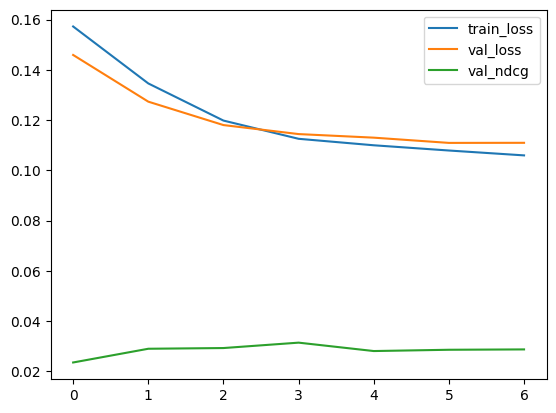

In [77]:
epochs = np.arange(len(list(trainer.history.values())[0]))
for v in trainer.history.values():
    plt.plot(epochs, v)
plt.legend(trainer.history.keys())

In [78]:
test_items = test_df.select(ITEM).unique(ITEM)
count_items = count_polars(test_items)

test = sample_polars(test_items, n_rows=TEST_ITEMS, id_columns=[ITEM])
cold_test = test.join(train_df.select(ITEM).unique(), on=ITEM, how="anti")

print(f"Test items: {count_polars(test)} Test cold items: {count_polars(cold_test)}")

Test items: 823 Test cold items: 157


In [79]:
solver = Solver(
    trainer=trainer,
    predict_items=test,
    candidates_to_keep=500,
    top_per_item=TOP_PER_ITEM,
    max_per_user=MAX_PER_USER,
)
trainer.model.eval()
solver.collect_candidates(users_batch_size=512, items_batch_size=2048)

Users:   0%|          | 0/4 [00:00<?, ?it/s]

Predict Items:   0%|          | 0/1 [00:00<?, ?it/s]

Clean up:   0%|          | 0/823 [00:00<?, ?it/s]

In [80]:
results = solver.solve()

predict = pl.DataFrame({
    ITEM: list(results.keys()),
    USER: [[u for u, _ in users_scores] for users_scores in results.values()]
})

In [81]:
for true, true_name in [
    (test_df.join(test, on=ITEM, how='inner'), "all"),
    (test_df.join(cold_test, on=ITEM, how='inner'), "cold")
]:
    true_agg = true.group_by(ITEM).agg(pl.col(USER)).collect()
    print(f"Test: {true_name} "
          f"Size: {true_agg.select(pl.len()).item()} "
          f"NDCG: {NDCG(predict.to_pandas(), true_agg.to_pandas()):.4f}")

Test: all Size: 823 NDCG: 0.0208
Test: cold Size: 157 NDCG: 0.0211
